In [1]:
## Day 6 work


# Cell 1 — Load everything saved from Day 5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")

# Load splits
X_train = pd.read_csv('../data/splits/X_train.csv')
X_test = pd.read_csv('../data/splits/X_test.csv')
y_train = pd.read_csv('../data/splits/y_train.csv').squeeze()
y_test = pd.read_csv('../data/splits/y_test.csv').squeeze()

# Load SMOTE balanced training data
X_train_smote = pd.read_csv('../data/splits/X_train_smote.csv')
y_train_smote = pd.read_csv(
    '../data/splits/y_train_smote.csv'
).squeeze()

print("✅ All data loaded!")
print(f"\nX_train_smote: {X_train_smote.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nTraining fraud count: {y_train_smote.sum():,}")
print(f"Test fraud count: {y_test.sum()}")

✅ All data loaded!

X_train_smote: (454902, 32)
X_test: (56962, 32)

Training fraud count: 227,451
Test fraud count: 98


In [2]:
# Cell 2 — What is Logistic Regression doing?
print("=== HOW LOGISTIC REGRESSION WORKS ===")
print("""
It learns a mathematical equation like:

Fraud Probability = sigmoid(
    w1*V14 + w2*V17 + w3*V12 + ... + w31*amount_log + bias
)

Where:
- w1, w2... = weights it learns from training data
- sigmoid = squishes output between 0 and 1
- Output > 0.5 → Fraud
- Output < 0.5 → Legit

It's the SIMPLEST classifier → perfect baseline
""")

=== HOW LOGISTIC REGRESSION WORKS ===

It learns a mathematical equation like:

Fraud Probability = sigmoid(
    w1*V14 + w2*V17 + w3*V12 + ... + w31*amount_log + bias
)

Where:
- w1, w2... = weights it learns from training data
- sigmoid = squishes output between 0 and 1
- Output > 0.5 → Fraud
- Output < 0.5 → Legit

It's the SIMPLEST classifier → perfect baseline



In [18]:
# Cell 3 — Train Logistic Regression
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,        # enough iterations to converge
    random_state=42,
    class_weight='balanced'  # extra safety for imbalance
)

lr_model.fit(X_train_smote, y_train_smote)

print("✅ Model trained!")
print(f"\nModel converged in: {lr_model.n_iter_[0]} iterations")
print(f"Number of features used: {lr_model.n_features_in_}")

Training Logistic Regression...
✅ Model trained!

Model converged in: 146 iterations
Number of features used: 32


In [19]:
# Cell 4 — Make predictions on TEST set
# Remember: test set is NEVER touched during training!

y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]
# [:, 1] means take probability of class 1 (fraud)

print("=== PREDICTIONS MADE ===")
print(f"Total test samples: {len(y_test):,}")
print(f"Predicted as Fraud: {y_pred.sum()}")
print(f"Actual Fraud: {y_test.sum()}")

=== PREDICTIONS MADE ===
Total test samples: 56,962
Predicted as Fraud: 1615
Actual Fraud: 98


In [5]:
# Cell 5 — Metric explanation
print("""
=== UNDERSTANDING METRICS ===

Confusion Matrix:
                 Predicted Legit    Predicted Fraud
Actual Legit  |  TN (correct)   |  FP (false alarm) |
Actual Fraud  |  FN (missed!)   |  TP (caught!)     |

For fraud detection:
- FN (False Negative) = MISSED FRAUD → very costly!
- FP (False Positive) = False alarm → annoying but ok

Metrics:
- Precision = TP / (TP + FP)  → of flagged frauds, how many real?
- Recall    = TP / (TP + FN)  → of real frauds, how many caught?
- F1        = balance of both
- AUC-ROC   = overall model quality (0.5=random, 1.0=perfect)

Target for this project:
✅ Recall > 0.85  (catch most frauds)
✅ AUC-ROC > 0.90 (good overall quality)
""")


=== UNDERSTANDING METRICS ===

Confusion Matrix:
                 Predicted Legit    Predicted Fraud
Actual Legit  |  TN (correct)   |  FP (false alarm) |
Actual Fraud  |  FN (missed!)   |  TP (caught!)     |

For fraud detection:
- FN (False Negative) = MISSED FRAUD → very costly!
- FP (False Positive) = False alarm → annoying but ok

Metrics:
- Precision = TP / (TP + FP)  → of flagged frauds, how many real?
- Recall    = TP / (TP + FN)  → of real frauds, how many caught?
- F1        = balance of both
- AUC-ROC   = overall model quality (0.5=random, 1.0=perfect)

Target for this project:
✅ Recall > 0.85  (catch most frauds)
✅ AUC-ROC > 0.90 (good overall quality)



In [20]:
# Cell 6 — Classification Report
print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Legit', 'Fraud']
))

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.98     56962



In [21]:
# Cell 7 — AUC-ROC Score
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC Score: {auc_score:.4f}")

if auc_score > 0.90:
    print("✅ Great baseline!")
elif auc_score > 0.80:
    print("⚠️ Decent baseline — XGBoost will improve this")
else:
    print("❌ Weak baseline — check your data pipeline")

AUC-ROC Score: 0.9707
✅ Great baseline!


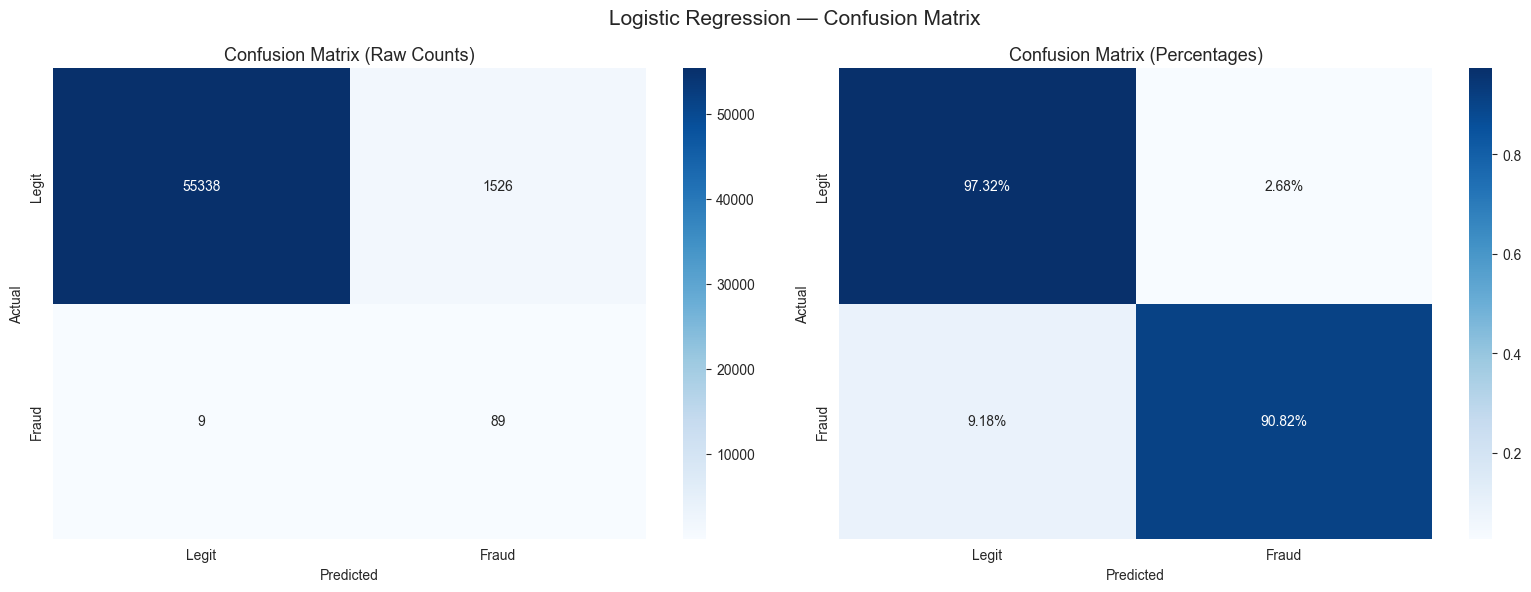


=== CONFUSION MATRIX BREAKDOWN ===
True Negatives  (Legit correctly identified): 55,338
False Positives (Legit flagged as Fraud):     1,526
False Negatives (Fraud missed!):              9
True Positives  (Fraud correctly caught):     89

Fraud Catch Rate: 90.8%
False Alarm Rate: 2.68%


In [8]:
# Cell 8 — Beautiful confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw numbers
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Percentages
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt='.2%',
            cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=13)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Logistic Regression — Confusion Matrix',
             fontsize=15)
plt.tight_layout()
plt.savefig('../data/lr_confusion_matrix.png')
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\n=== CONFUSION MATRIX BREAKDOWN ===")
print(f"True Negatives  (Legit correctly identified): {tn:,}")
print(f"False Positives (Legit flagged as Fraud):     {fp:,}")
print(f"False Negatives (Fraud missed!):              {fn}")
print(f"True Positives  (Fraud correctly caught):     {tp}")
print(f"\nFraud Catch Rate: {tp/(tp+fn)*100:.1f}%")
print(f"False Alarm Rate: {fp/(fp+tn)*100:.2f}%")

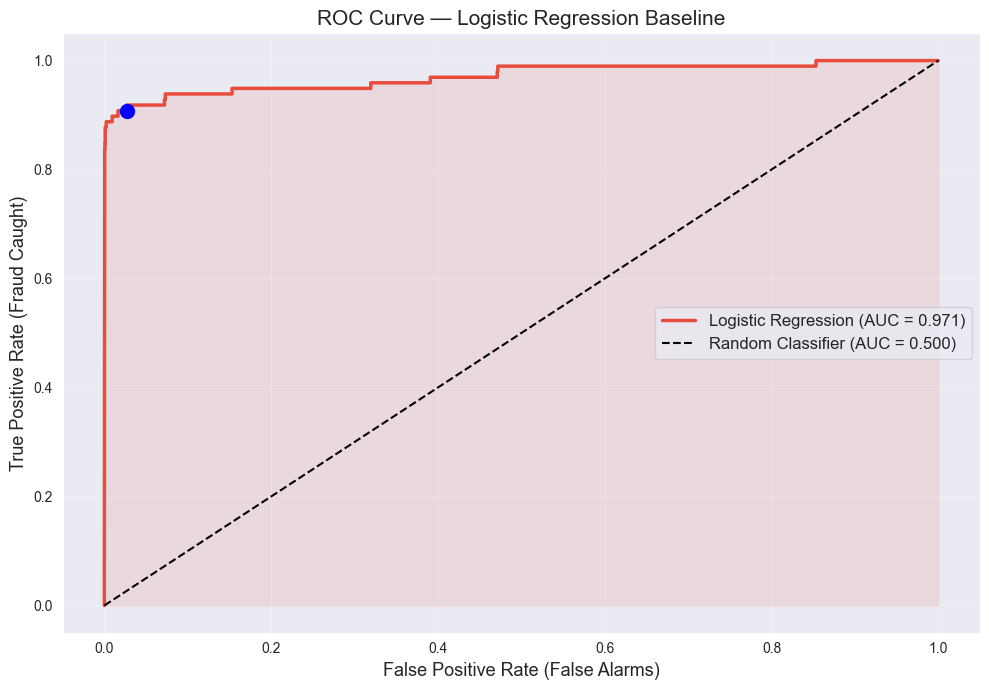

✅ AUC-ROC: 0.9707
(Closer to 1.0 = better | 0.5 = random guessing)


In [9]:
# Cell 9 — ROC Curve
# ROC curve shows tradeoff between catching fraud (TPR)
# and false alarms (FPR) at different thresholds

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(10, 7))

# Plot ROC curve
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2.5,
         label=f'Logistic Regression (AUC = {auc_score:.3f})')

# Plot random classifier line (worst case)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5,
         label='Random Classifier (AUC = 0.500)')

# Formatting
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate (False Alarms)', fontsize=13)
plt.ylabel('True Positive Rate (Fraud Caught)', fontsize=13)
plt.title('ROC Curve — Logistic Regression Baseline',
          fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Mark the point where threshold = 0.5
threshold_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[threshold_idx], tpr[threshold_idx],
            color='blue', s=100, zorder=5,
            label=f'Threshold=0.5')

plt.tight_layout()
plt.savefig('../data/lr_roc_curve.png')
plt.show()

print(f"✅ AUC-ROC: {auc_score:.4f}")
print("(Closer to 1.0 = better | 0.5 = random guessing)")

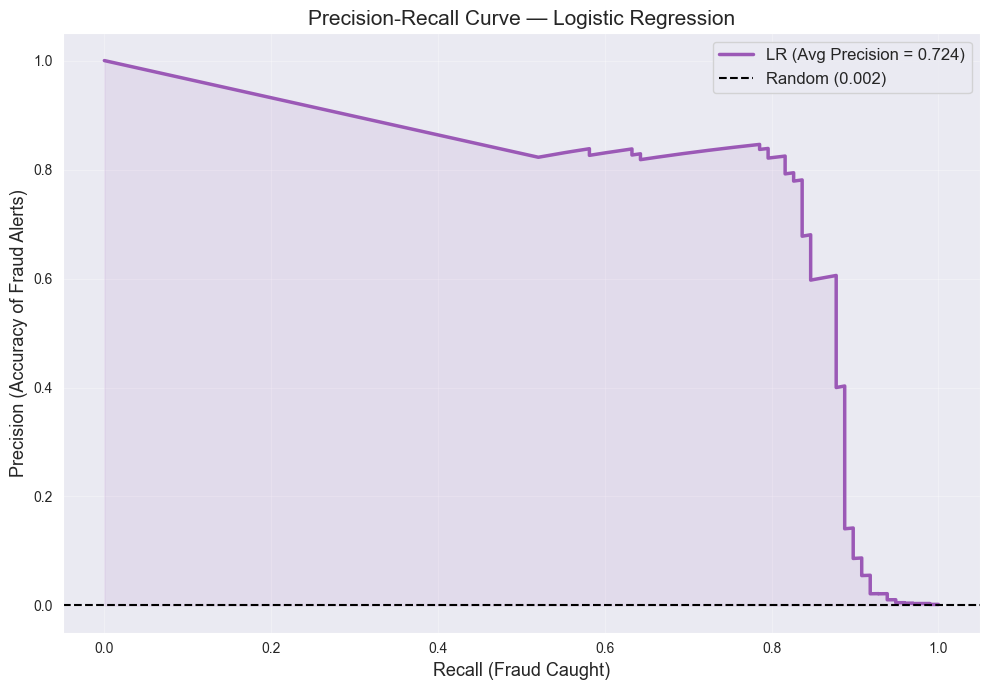

✅ Average Precision: 0.7238

PR Curve tells you:
- High recall + high precision = perfect model
- Tradeoff: catching more fraud → more false alarms



In [10]:
# Cell 10 — Precision-Recall Curve
# More useful than ROC for imbalanced datasets!

precision, recall, pr_thresholds = precision_recall_curve(
    y_test, y_prob
)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(10, 7))

plt.plot(recall, precision, color='#9b59b6',
         linewidth=2.5,
         label=f'LR (Avg Precision = {avg_precision:.3f})')

# Random baseline for PR curve
random_baseline = y_test.sum() / len(y_test)
plt.axhline(y=random_baseline, color='k',
            linestyle='--', linewidth=1.5,
            label=f'Random ({random_baseline:.3f})')

plt.xlabel('Recall (Fraud Caught)', fontsize=13)
plt.ylabel('Precision (Accuracy of Fraud Alerts)', fontsize=13)
plt.title('Precision-Recall Curve — Logistic Regression',
          fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.fill_between(recall, precision, alpha=0.1, color='#9b59b6')

plt.tight_layout()
plt.savefig('../data/lr_pr_curve.png')
plt.show()

print(f"✅ Average Precision: {avg_precision:.4f}")
print("""
PR Curve tells you:
- High recall + high precision = perfect model
- Tradeoff: catching more fraud → more false alarms
""")

=== TOP 15 MOST IMPORTANT FEATURES ===
      Feature  Coefficient  Abs_Coefficient
amount_scaled     3.115869         3.115869
  hour_scaled     1.857971         1.857971
          V20    -1.703336         1.703336
          V14    -1.701312         1.701312
          V10    -1.536447         1.536447
          V12    -1.401553         1.401553
          V28     1.330632         1.330632
          V16    -1.274125         1.274125
          V17    -1.256469         1.256469
           V5     1.081189         1.081189
           V1     1.043930         1.043930
           V4     1.026209         1.026209
           V7    -0.920986         0.920986
           V2     0.919520         0.919520
          V23     0.788982         0.788982


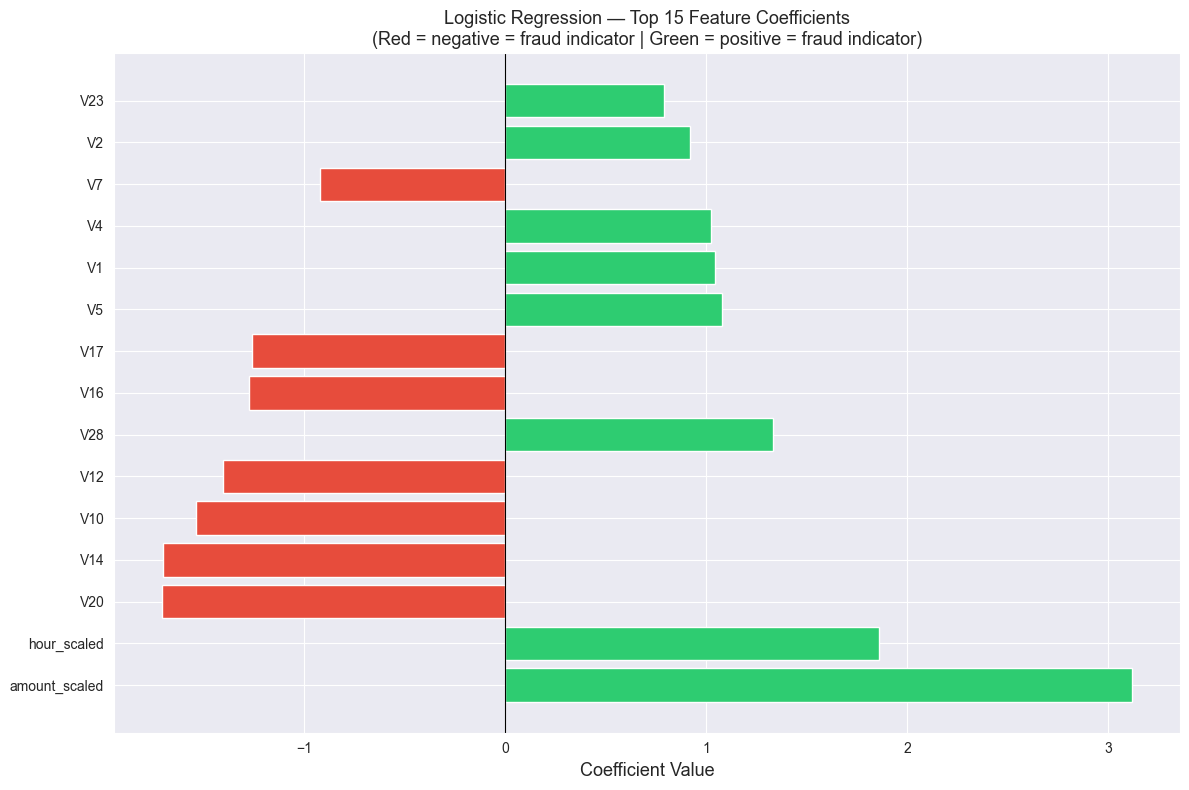


✅ Notice V14, V17 are top features — matches our EDA!


In [11]:
# Cell 11 — Which features does LR think matter most?
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("=== TOP 15 MOST IMPORTANT FEATURES ===")
print(feature_importance.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(12, 8))
top15 = feature_importance.head(15)

colors = ['#e74c3c' if c < 0 else '#2ecc71'
          for c in top15['Coefficient']]

plt.barh(top15['Feature'], top15['Coefficient'], color=colors)
plt.xlabel('Coefficient Value', fontsize=13)
plt.title('Logistic Regression — Top 15 Feature Coefficients\n'
          '(Red = negative = fraud indicator | '
          'Green = positive = fraud indicator)',
          fontsize=13)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../data/lr_feature_importance.png')
plt.show()

print("\n✅ Notice V14, V17 are top features — matches our EDA!")

In [12]:
# Cell 12 — Save all baseline metrics
import json

baseline_results = {
    'model': 'Logistic Regression',
    'auc_roc': round(float(auc_score), 4),
    'avg_precision': round(float(avg_precision), 4),
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report(
        y_test, y_pred,
        target_names=['Legit', 'Fraud'],
        output_dict=True
    )
}

with open('../models/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print("✅ Baseline results saved!")
print(f"\n=== BASELINE TO BEAT ===")
print(f"AUC-ROC:       {auc_score:.4f}")
print(f"Avg Precision: {avg_precision:.4f}")
print(f"Fraud Recall:  {baseline_results['classification_report']['Fraud']['recall']:.4f}")
print(f"\nXGBoost on Day 8 should beat all of these!")


✅ Baseline results saved!

=== BASELINE TO BEAT ===
AUC-ROC:       0.9707
Avg Precision: 0.7238
Fraud Recall:  0.9082

XGBoost on Day 8 should beat all of these!
